In [1]:
# lab 30
# Unsupervised Learning: Mall Customer Segmentation 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# clustering
from sklearn.cluster import KMeans

# evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples
)

# warnings
import warnings
warnings.filterwarnings('ignore')

# style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")




In [ ]:
# section 1 load and explore the dataset



print("Loading dataset...")

df = pd.read_csv("../../../../../datasets/Mall_Customers.csv")
print("Dataset loaded successfully!")


print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print(f"\nMissing Values: {df.isnull().sum().sum()}")




Loading dataset...
Dataset loaded successfully!

Dataset Shape: 200 rows, 5 columns

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: in

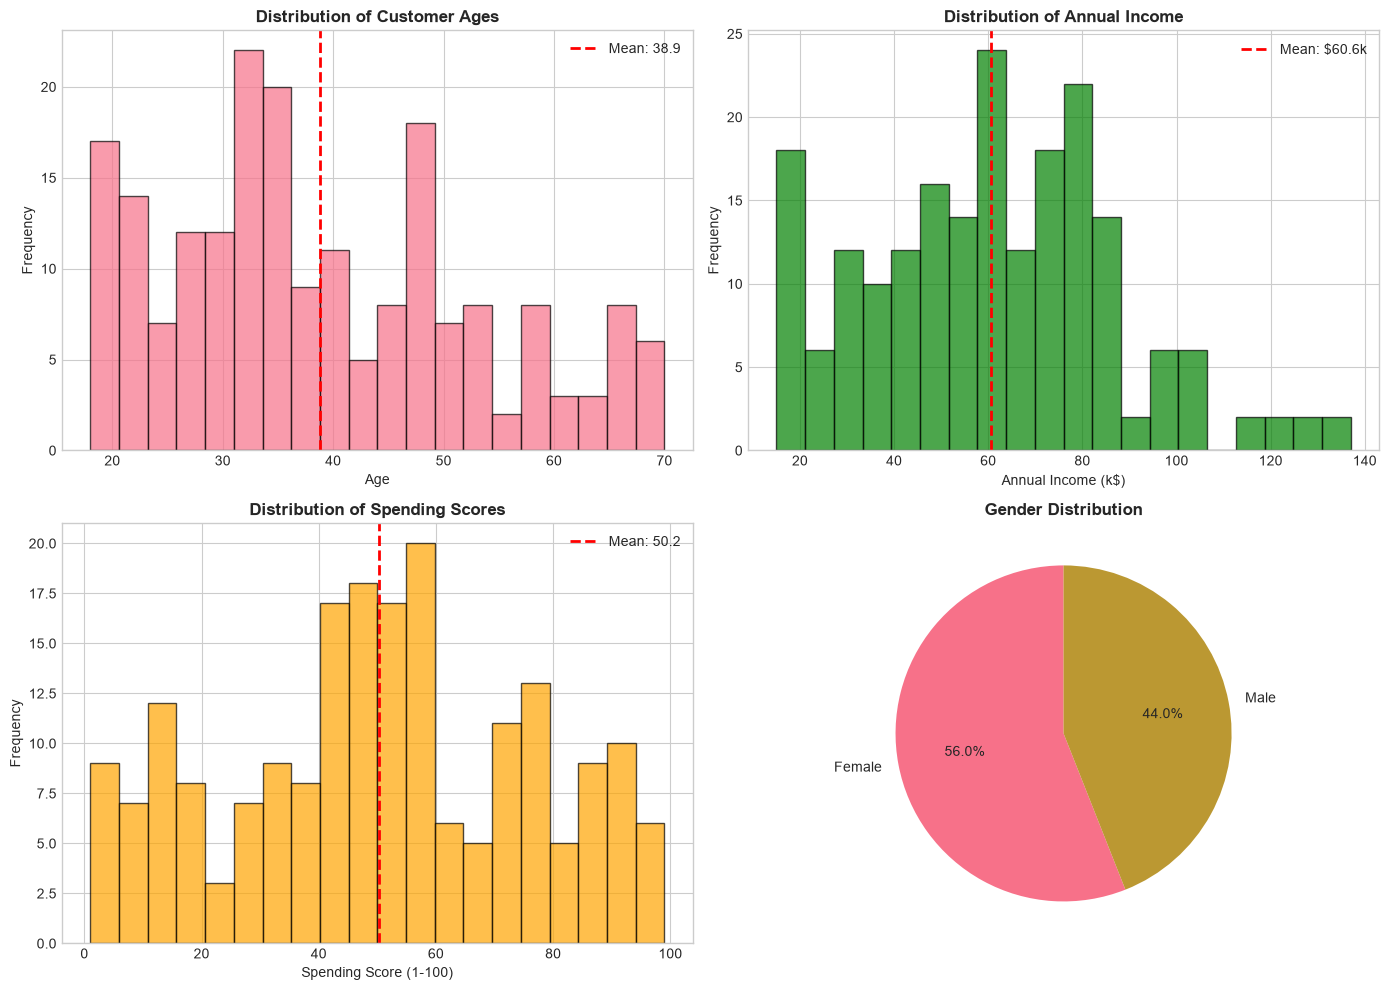

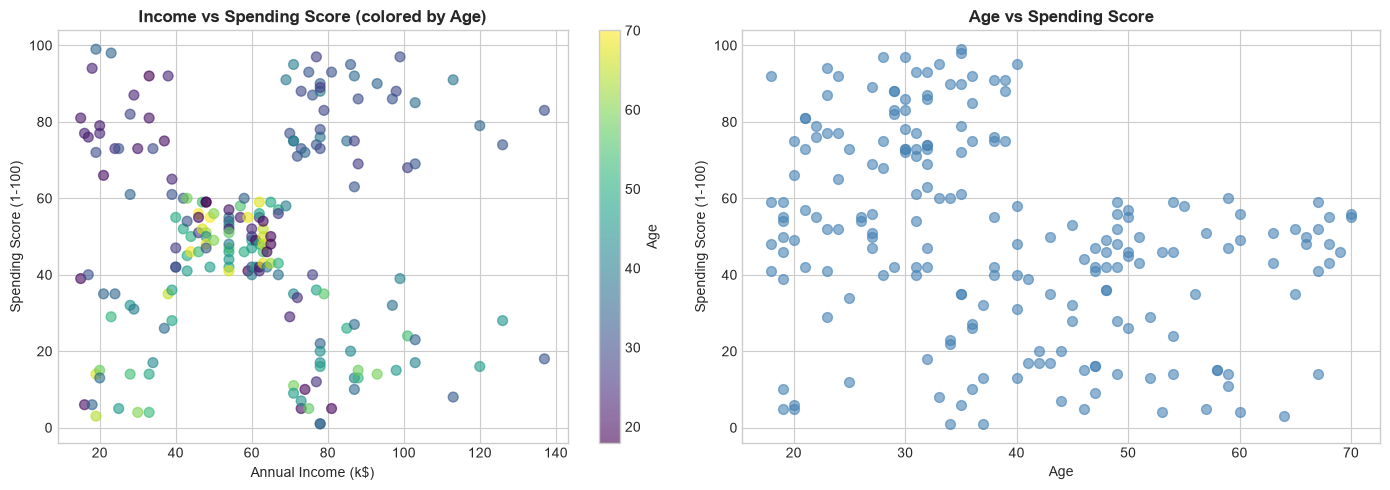

In [17]:
# Section 2  Exploratory Data Analysis

#Distributions of Age, Income, and Spending Score 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
axes[0, 0].hist(df['Age'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['Age'].mean(), color='red', linestyle='dashed',
                   linewidth=2, label=f"Mean: {df['Age'].mean():.1f}")
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Customer Ages', fontweight='bold')
axes[0, 0].legend()

# Income distribution
axes[0, 1].hist(df['Annual Income (k$)'], bins=20, edgecolor='black',
                alpha=0.7, color='green')
axes[0, 1].axvline(df['Annual Income (k$)'].mean(), color='red',
                   linestyle='dashed', linewidth=2,
                   label=f"Mean: ${df['Annual Income (k$)'].mean():.1f}k")
axes[0, 1].set_xlabel('Annual Income (k$)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Annual Income', fontweight='bold')
axes[0, 1].legend()

# Spending Score distribution
axes[1, 0].hist(df['Spending Score (1-100)'], bins=20, edgecolor='black',
                alpha=0.7, color='orange')
axes[1, 0].axvline(df['Spending Score (1-100)'].mean(), color='red',
                   linestyle='dashed', linewidth=2,
                   label=f"Mean: {df['Spending Score (1-100)'].mean():.1f}")
axes[1, 0].set_xlabel('Spending Score (1-100)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Spending Scores', fontweight='bold')
axes[1, 0].legend()

# Gender distribution (pie chart)
gender_counts = df['Gender'].value_counts()
axes[1, 1].pie(gender_counts.values, labels=gender_counts.index,
               autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Gender Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

#Relationships between features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income vs Spending Score colored by Age
scatter = axes[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                          c=df['Age'], cmap='viridis', alpha=0.6, s=50)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('Income vs Spending Score (colored by Age)', fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Age')

# Age vs Spending Score
axes[1].scatter(df['Age'], df['Spending Score (1-100)'], alpha=0.6,
                c='steelblue', s=50)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].set_title('Age vs Spending Score', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_relationships.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
Checkpoint: Based on the Income vs. Spending Score scatter plot, how many natural groupings do you think are visible, 
and why? 

About 4–5 natural groupings are visible, reflecting low-income/low-spenders, low-income/high-spenders, high-income/low-spenders, high-income/high-spenders, and a middle-income mixed group.

In [ ]:
#section 3 Data Preprocessing 

# select features for clustering
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

print(f"Selected features: {features}")
print(f"Feature matrix shape: {X.shape}")

# standardize the features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✅ Features standardized (mean=0, std=1)")

# sample of scaled features
print("\nSample of scaled features (first 10 rows):")
print(pd.DataFrame(X_scaled[:10], columns=['Scaled Income', 'Scaled Spending']))


Selected features: ['Annual Income (k$)', 'Spending Score (1-100)']
Feature matrix shape: (200, 2)
✅ Features standardized (mean=0, std=1)

Sample of scaled features (first 10 rows):
   Scaled Income  Scaled Spending
0      -1.738999        -0.434801
1      -1.738999         1.195704
2      -1.700830        -1.715913
3      -1.700830         1.040418
4      -1.662660        -0.395980
5      -1.662660         1.001596
6      -1.624491        -1.715913
7      -1.624491         1.700384
8      -1.586321        -1.832378
9      -1.586321         0.846310


Checkpoint Question
Why is standardization important specifically for K-Means, and what could go wrong if you skipped it?

Without scaling, Annual Income (k$) (values up to ~137) would dominate over Spending Score (1–100).
clusters would be biased toward income differences, ignoring spending behavior.

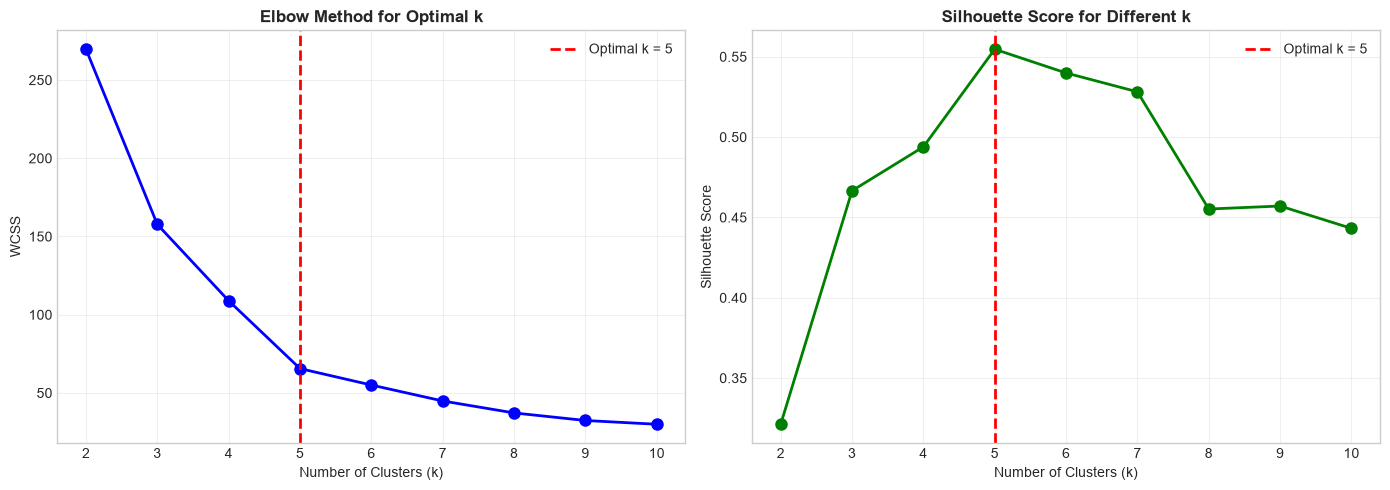


Optimal number of clusters determined: k = 5
(Based on elbow point at k=5 and high silhouette score)


In [ ]:
# 4 finding the Optimal Number of Clusters
# calculate WCSS( within-cluster sum of squares () and silhouette score for a range of k values
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k, 
        init='k-means++', 
        random_state=42, 
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# plot results side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# elbow Method
axes[0].plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal k = 5')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS')
axes[0].set_title('Elbow Method for Optimal k', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# silhouette Scores
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal k = 5')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different k', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('optial_K_determination.png', dpi=300, bbox_inches='tight')
plt.show()

# decide optimal k
optimal_k = 5
print(f"\nOptimal number of clusters determined: k = {optimal_k}")
print("(Based on elbow point at k=5 and high silhouette score)")


Checkpoint: Where does the elbow occur in your WCSS plot, and does it agree with where the silhouette score is highest? 
What value of k will you use going forward?

The elbow in the WCSS plot occurs at k = 5, where the curve stops dropping sharply and begins to flatten. This matches the silhouette score, which also shows a relatively high value at k = 5, indicating well-separated clusters.

So both methods agree, and the optimal number of clusters going forward is k = 5

This means we will apply K-Means with 5 clusters in the next step to segment the customers into distinct groups.

In [ ]:
# section 5 applying k-means clustering 
kmeans = 